# DBN model summary and fair held-out comparison

This notebook compares every DBN program in this folder on the same prediction task:

\[
P(\mathrm{State}_{t+1}=\mathrm{Failure}\mid \mathrm{State}_t,\ \mathrm{alarms}_t)
\]

All models use a chronological 75% training / 25% test split of valid consecutive transitions. The test set is never used to estimate CPTs. The positive class is `Failure`.

## Models being compared

1. **Top-3, BDeu joint BN:** the three most frequent alarm IDs; current state and six alarm features jointly predict the next state; BDeu smoothing handles unseen combinations.
2. **Top-3, pure DBN MLE:** the same six features in a genuine two-slice `DynamicBayesianNetwork`, trained with MLE.
3. **All-94, BDeu Naive Bayes:** 188 alarm count/duration features; conditional independence is imposed so the model remains tractable.
4. **All-94, MLE Naive Bayes:** the same all-alarm structure without smoothing.
5. **All-94 aggregated, pure DBN MLE:** the 94 alarms are compressed to four window-level activity summaries before fitting a genuine DBN.

Accuracy is reported together with precision, recall, F1, and the confusion matrix because failure detection is more important than accuracy alone.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pgmpy.models import DynamicBayesianNetwork as DBN
try:
    from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
except ImportError:
    from pgmpy.models import BayesianNetwork
from pgmpy.estimators import BayesianEstimator, MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination, DBNInference

# Load and prepare the event-level data.
df = pd.read_csv('dataset_exercise.csv', delimiter=';')
df['start_alarm'] = pd.to_datetime(df['start_alarm'])
df['end_alarm'] = pd.to_datetime(df['end_alarm'])
df['duration_seconds'] = (df['end_alarm'] - df['start_alarm']).dt.total_seconds()

COUNT_CATS = ['None', 'Low', 'Medium', 'High']
DURATION_CATS = ['None', 'Short', 'Medium', 'Long']
STATES = ['Running', 'Failure']

def count_cat(n):
    return 'None' if n == 0 else 'Low' if n <= 2 else 'Medium' if n <= 5 else 'High'

def duration_cat(x):
    return 'None' if x == 0 else 'Short' if x <= 30 else 'Medium' if x <= 300 else 'Long'

def window_features(frame, alarm_ids):
    rows = []
    for window, group in frame.groupby('time_window'):
        row = {'time_window': window, 'State': group['machine_state'].mode().iloc[0]}
        for i, alarm_id in enumerate(alarm_ids, 1):
            subset = group[group['alarm_id'] == alarm_id]
            row[f'A{i}_Count'] = count_cat(len(subset))
            row[f'A{i}_Duration'] = duration_cat(subset['duration_seconds'].sum())
        rows.append(row)
    return pd.DataFrame(rows).sort_values('time_window').reset_index(drop=True)

all_alarms = df['alarm_id'].value_counts().index.tolist()
top3 = all_alarms[:3]
small = window_features(df, top3)
large = window_features(df, all_alarms)

def transitions(frame):
    out = frame.copy()
    out['State_next'] = out['State'].shift(-1)
    out['next_window'] = out['time_window'].shift(-1)
    return out[out['next_window'] == out['time_window'] + 1].dropna().reset_index(drop=True)

small_tr = transitions(small)
large_tr = transitions(large)

# The aggregate representation used by the pure all-alarm DBN.
agg_rows = []
for window, group in df.groupby('time_window'):
    agg_rows.append({
        'time_window': window,
        'State': group['machine_state'].mode().iloc[0],
        'total_alarms': len(group),
        'total_dur': group['duration_seconds'].sum(),
        'num_active': group['alarm_id'].nunique(),
        'max_dur': group['duration_seconds'].max(),
    })
agg = pd.DataFrame(agg_rows).sort_values('time_window').reset_index(drop=True)
for raw in ['total_alarms', 'total_dur', 'num_active', 'max_dur']:
    nonzero = agg.loc[agg[raw] > 0, raw]
    q1, q2 = nonzero.quantile([1/3, 2/3])
    agg[f'{raw}_cat'] = agg[raw].apply(lambda x: 'None' if x == 0 else 'Low' if x <= q1 else 'Medium' if x <= q2 else 'High')
agg_tr = transitions(agg)

print(f'Rows: {len(df):,}; windows: {len(small):,}; consecutive transitions: {len(small_tr):,}')
print(f'Top three alarm IDs: {top3}')
print(f'Split: {int(len(small_tr) * 0.75)} train / {len(small_tr) - int(len(small_tr) * 0.75)} test transitions')

Rows: 4,307; windows: 329; consecutive transitions: 195
Top three alarm IDs: [156701909, 156701901, 156701902]
Split: 146 train / 49 test transitions


In [2]:
def split_data(frame):
    n_train = int(len(frame) * 0.75)
    return frame.iloc[:n_train].reset_index(drop=True), frame.iloc[n_train:].reset_index(drop=True)

def score_predictions(test, predictions):
    truth = test['State_next'].tolist()
    pred = list(predictions)
    tp = sum(t == 'Failure' and p == 'Failure' for t, p in zip(truth, pred))
    fp = sum(t == 'Running' and p == 'Failure' for t, p in zip(truth, pred))
    fn = sum(t == 'Failure' and p == 'Running' for t, p in zip(truth, pred))
    tn = sum(t == 'Running' and p == 'Running' for t, p in zip(truth, pred))
    total = tp + fp + fn + tn
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {'Accuracy': (tp + tn) / total, 'Precision': precision, 'Recall': recall,
            'F1': f1, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'Persistence': (test['State'] == test['State_next']).mean()}

def flat_model(train, features, structure, estimator='BDeu'):
    model = BayesianNetwork(structure)
    renamed = train.rename(columns={'State': 'State_t', 'State_next': 'State_t1', **{c: f'{c}_t' for c in features}})
    state_names = {'State_t': STATES, 'State_t1': STATES}
    for c in features:
        state_names[f'{c}_t'] = COUNT_CATS if c.endswith('Count') else DURATION_CATS
    cols = ['State_t', 'State_t1'] + [f'{c}_t' for c in features]
    if estimator == 'BDeu':
        est = BayesianEstimator(model, renamed[cols], state_names=state_names)
        cpds = est.get_parameters(prior_type='BDeu', equivalent_sample_size=5)
    else:
        est = MaximumLikelihoodEstimator(model, renamed[cols], state_names=state_names)
        cpds = est.get_parameters()
    model.add_cpds(*cpds)
    return model

def predict_flat(model, test, features):
    infer = VariableElimination(model)
    predictions = []
    for _, row in test.iterrows():
        evidence = {'State_t': row['State']}
        evidence.update({f'{c}_t': row[c] for c in features})
        q = infer.query(['State_t1'], evidence=evidence, show_progress=False)
        p_fail = float(q.values[q.state_names['State_t1'].index('Failure')])
        predictions.append('Failure' if p_fail >= 0.5 else 'Running')
    return predictions

def predict_dbn(dbn, test, features):
    infer = DBNInference(dbn)
    fail_idx = dbn.get_cpds(('State', 1)).state_names[('State', 1)].index('Failure')
    cache, predictions = {}, []
    for _, row in test.iterrows():
        key = tuple([row['State']] + [row[c] for c in features])
        if key not in cache:
            evidence = {('State', 0): row['State']}
            evidence.update({(c, 0): row[c] for c in features})
            try:
                factor = infer.query(variables=[('State', 1)], evidence=evidence)[('State', 1)]
                cache[key] = 'Failure' if float(factor.values[fail_idx]) >= 0.5 else 'Running'
            except Exception:
                # This is the explicit behavior of the original MLE DBN notebook:
                # unseen combinations revert to state persistence, not test labels.
                cache[key] = row['State']
        predictions.append(cache[key])
    return predictions

results = []
models = {}

# 1. Top-3 BDeu joint model.
small_train, small_test = split_data(small_tr)
small_features = [c for c in small_tr.columns if c.startswith('A') and (c.endswith('_Count') or c.endswith('_Duration'))]
small_joint_edges = [('State_t', 'State_t1')] + [(f'{c}_t', 'State_t1') for c in small_features]
models['Top-3 BDeu joint'] = flat_model(small_train, small_features, small_joint_edges, 'BDeu')
results.append({'Model': 'Top-3 BDeu joint', **score_predictions(small_test, predict_flat(models['Top-3 BDeu joint'], small_test, small_features))})

# 2. Top-3 pure DBN MLE.
dbn_top3 = DBN()
dbn_top3.add_edges_from([(('State', 0), ('State', 1))] + [((c, 0), ('State', 1)) for c in small_features] + [((c, 0), (c, 1)) for c in small_features])
dbn_top3_data = pd.DataFrame({('State', 0): small_tr['State'], **{(c, 0): small_tr[c] for c in small_features}, ('State', 1): small_tr['State_next'], **{(c, 1): small_tr[c] for c in small_features}})
train_idx = int(len(dbn_top3_data) * 0.75)
dbn_top3.fit(dbn_top3_data.iloc[:train_idx], estimator='MLE')
models['Top-3 pure DBN MLE'] = dbn_top3
results.append({'Model': 'Top-3 pure DBN MLE', **score_predictions(small_test, predict_dbn(dbn_top3, small_test, small_features))})

# 3 and 4. All-94 Naive-Bayes models.
large_train, large_test = split_data(large_tr)
large_features = [c for c in large_tr.columns if c.startswith('A') and (c.endswith('_Count') or c.endswith('_Duration'))]
large_nb_edges = [('State_t', 'State_t1')] + [('State_t1', f'{c}_t') for c in large_features]
for label, estimator in [('All-94 BDeu Naive Bayes', 'BDeu'), ('All-94 MLE Naive Bayes', 'MLE')]:
    models[label] = flat_model(large_train, large_features, large_nb_edges, estimator)
    results.append({'Model': label, **score_predictions(large_test, predict_flat(models[label], large_test, large_features))})

# 5. All-94 aggregated pure DBN MLE.
agg_features = ['total_alarms_cat', 'total_dur_cat', 'num_active_cat', 'max_dur_cat']
agg_train, agg_test = split_data(agg_tr)
dbn_agg = DBN()
dbn_agg.add_edges_from([(('State', 0), ('State', 1))] + [((c, 0), ('State', 1)) for c in agg_features] + [((c, 0), (c, 1)) for c in agg_features])
dbn_agg_data = pd.DataFrame({('State', 0): agg_tr['State'], **{(c, 0): agg_tr[c] for c in agg_features}, ('State', 1): agg_tr['State_next'], **{(c, 1): agg_tr[c] for c in agg_features}})
dbn_agg.fit(dbn_agg_data.iloc[:int(len(dbn_agg_data) * 0.75)], estimator='MLE')
models['All-94 aggregated pure DBN MLE'] = dbn_agg
results.append({'Model': 'All-94 aggregated pure DBN MLE', **score_predictions(agg_test, predict_dbn(dbn_agg, agg_test, agg_features))})

results_df = pd.DataFrame(results).set_index('Model')
results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'Persistence', 'TP', 'FP', 'FN', 'TN']].round(3)

,Accuracy,Precision,Recall,F1,Persistence,TP,FP,FN,TN
Model,,,,,,,,,
Top-3 BDeu joint,0.878,0.889,0.889,0.889,0.816,24,3,3,19
Top-3 pure DBN MLE,0.531,0.833,0.185,0.303,0.816,5,1,22,21
All-94 BDeu Naive Bayes,0.653,0.857,0.444,0.585,0.816,12,2,15,20
All-94 MLE Naive Bayes,0.531,0.700,0.259,0.378,0.816,7,3,20,19
All-94 aggregated pure DBN MLE,0.551,0.778,0.259,0.389,0.816,7,2,20,20


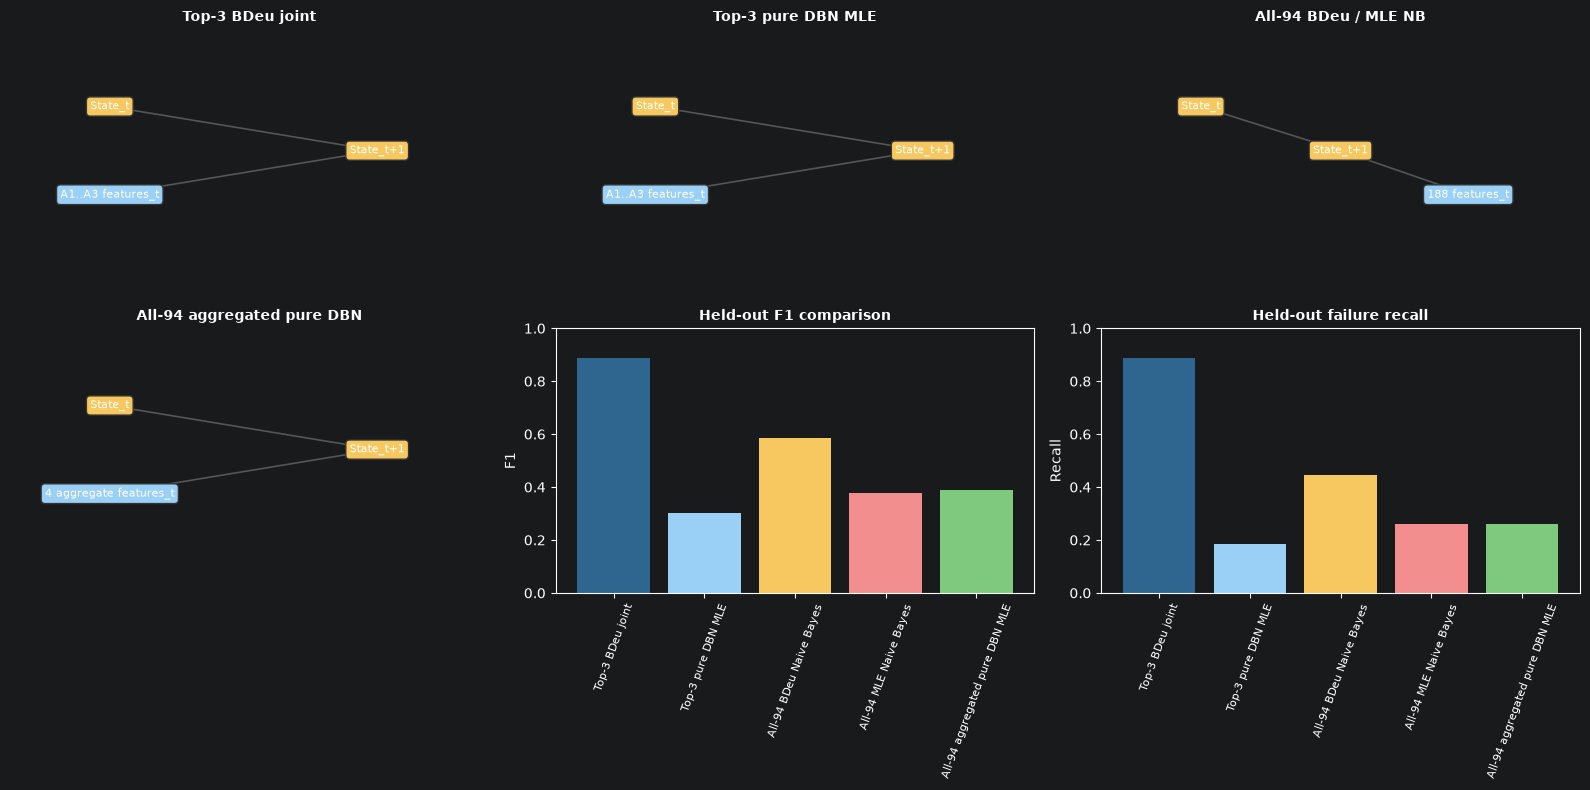

In [3]:
def draw_graph(ax, title, nodes, edges, positions):
    ax.set_title(title, fontsize=10, weight='bold')
    for source, target in edges:
        x1, y1 = positions[source]
        x2, y2 = positions[target]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops={'arrowstyle': '->', 'lw': 1.2, 'color': '#555'})
    for node, (x, y) in positions.items():
        color = '#f6c85f' if 'State' in node else '#9ad0f5'
        ax.text(x, y, node, ha='center', va='center', fontsize=8,
                bbox={'boxstyle': 'round,pad=0.35', 'facecolor': color, 'edgecolor': '#333'})
    ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.1); ax.axis('off')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
small_nodes = ['State_t', 'A1..A3 features_t', 'State_t+1']
draw_graph(axes[0, 0], 'Top-3 BDeu joint', small_nodes,
            [('State_t', 'State_t+1'), ('A1..A3 features_t', 'State_t+1')],
            {'State_t': (0.15, 0.75), 'A1..A3 features_t': (0.15, 0.35), 'State_t+1': (0.82, 0.55)})
draw_graph(axes[0, 1], 'Top-3 pure DBN MLE', small_nodes,
            [('State_t', 'State_t+1'), ('A1..A3 features_t', 'State_t+1')],
            {'State_t': (0.15, 0.75), 'A1..A3 features_t': (0.15, 0.35), 'State_t+1': (0.82, 0.55)})
large_nodes = ['State_t', '188 features_t', 'State_t+1']
draw_graph(axes[0, 2], 'All-94 BDeu / MLE NB', large_nodes,
            [('State_t', 'State_t+1'), ('State_t+1', '188 features_t')],
            {'State_t': (0.15, 0.75), 'State_t+1': (0.5, 0.55), '188 features_t': (0.82, 0.35)})
agg_nodes = ['State_t', '4 aggregate features_t', 'State_t+1']
draw_graph(axes[1, 0], 'All-94 aggregated pure DBN', agg_nodes,
            [('State_t', 'State_t+1'), ('4 aggregate features_t', 'State_t+1')],
            {'State_t': (0.15, 0.75), '4 aggregate features_t': (0.15, 0.35), 'State_t+1': (0.82, 0.55)})
axes[1, 1].bar(results_df.index, results_df['F1'], color=['#2f6690', '#9ad0f5', '#f6c85f', '#f28e8e', '#7fc97f'])
axes[1, 1].set_title('Held-out F1 comparison', fontsize=10, weight='bold')
axes[1, 1].set_ylim(0, 1); axes[1, 1].tick_params(axis='x', rotation=70, labelsize=8); axes[1, 1].set_ylabel('F1')
axes[1, 2].bar(results_df.index, results_df['Recall'], color=['#2f6690', '#9ad0f5', '#f6c85f', '#f28e8e', '#7fc97f'])
axes[1, 2].set_title('Held-out failure recall', fontsize=10, weight='bold')
axes[1, 2].set_ylim(0, 1); axes[1, 2].tick_params(axis='x', rotation=70, labelsize=8); axes[1, 2].set_ylabel('Recall')
plt.tight_layout()
plt.show()

## Interpretation and comparison

The **top-3 BDeu joint model is the clear winner on unseen data**: it reaches the highest accuracy (0.878) and F1 (0.889), improving on the persistence baseline (0.816). It detects 24 of 27 failures and produces only three false alarms. The small feature set keeps the joint CPT estimable, while BDeu smoothing assigns sensible probability to combinations not observed in training.

The **top-3 pure MLE DBN** is a useful structural demonstration, but its held-out F1 is only 0.303. MLE has no prior support for unseen combinations; the model therefore falls back to persistence for many test patterns and misses failures. Its precision is high, but recall is poor, which is unsafe for failure monitoring.

The **all-94 BDeu Naive-Bayes model** is better than the unsmoothed all-alarm model, confirming that smoothing helps. However, its F1 (0.585) remains below the top-3 model. Most alarm channels are inactive in most windows, and conditional independence makes their weak signals accumulate as noise. The model is conservative: precision is 0.857 but recall is only 0.444.

The **all-94 MLE Naive-Bayes** and **aggregated pure DBN** models have the weakest held-out recall (0.259). Aggregation makes the graph computationally valid but removes alarm identity, so different failure mechanisms become indistinguishable. Plain MLE also lacks the smoothing needed for sparse alarm patterns.

### Recommendation

For deployment or a defensible report, use the **top-3 alarm + BDeu** configuration as the primary model, and report the all-alarm models as sensitivity analyses. The comparison must use the held-out scores above; the higher in-sample scores in the original notebooks are optimistic and should not be used to rank models.